<a href="https://colab.research.google.com/github/enockmugisha1/linear_regression_model/blob/main/multivariate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Predicting Starting Salary from Education & Career Features
### Mission: Help students and career advisors understand which academic and career-related factors most influence starting salary after graduation.
### Dataset Source: Kaggle — Education & Career Success Dataset
---

##  Step 1: Install & Import Libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

import joblib
import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully!')

All libraries imported successfully!


In [7]:
# No need to mount Google Drive — dataset loads directly from GitHub
print("Dataset will be loaded from GitHub raw URL below.")

Dataset will be loaded from GitHub raw URL below.


##  Step 2: Load the Dataset

In [8]:
# Load dataset directly from GitHub (works on Colab without uploading any file)
url = "https://raw.githubusercontent.com/enockmugisha1/linear_regression_model/main/education_career_success%20(1).csv"
df = pd.read_csv(url)

print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
df.head()

Shape: (400, 19)

Columns: ['Student_ID', 'Age', 'Gender', 'High_School_GPA', 'SAT_Score', 'University_GPA', 'Field_of_Study', 'Internships_Completed', 'Projects_Completed', 'Certifications', 'Soft_Skills_Score', 'Networking_Score', 'Job_Offers', 'Starting_Salary', 'Career_Satisfaction', 'Years_to_Promotion', 'Current_Job_Level', 'Work_Life_Balance', 'Entrepreneurship']


,Student_ID,Age,Gender,High_School_GPA,SAT_Score,University_GPA,Field_of_Study,Internships_Completed,Projects_Completed,Certifications,Soft_Skills_Score,Networking_Score,Job_Offers,Starting_Salary,Career_Satisfaction,Years_to_Promotion,Current_Job_Level,Work_Life_Balance,Entrepreneurship
0,S001,22,Male,3.8,1450,3.6,Computer Science,3,7,2,8,7,3,85000,8,2,Mid,7,No
1,S002,24,Female,3.6,1380,3.4,Business,2,5,3,7,6,2,65000,7,3,Mid,6,No
2,S003,21,Male,3.9,1520,3.8,Engineering,4,9,4,9,8,4,120000,9,1,Senior,6,No
3,S004,23,Female,3.5,1300,3.2,Psychology,1,3,1,6,5,1,48000,6,4,Entry,8,No
4,S005,25,Male,3.7,1420,3.5,Medicine,2,6,2,8,7,3,95000,8,2,Mid,5,No


In [9]:
print('Missing values:')
print(df.isnull().sum())
print('\nData types:')
print(df.dtypes)

Missing values:
Student_ID               0
Age                      0
Gender                   0
High_School_GPA          0
SAT_Score                0
University_GPA           0
Field_of_Study           0
Internships_Completed    0
Projects_Completed       0
Certifications           0
Soft_Skills_Score        0
Networking_Score         0
Job_Offers               0
Starting_Salary          0
Career_Satisfaction      0
Years_to_Promotion       0
Current_Job_Level        0
Work_Life_Balance        0
Entrepreneurship         0
dtype: int64

Data types:
Student_ID                object
Age                        int64
Gender                    object
High_School_GPA          float64
SAT_Score                  int64
University_GPA           float64
Field_of_Study            object
Internships_Completed      int64
Projects_Completed         int64
Certifications             int64
Soft_Skills_Score          int64
Networking_Score           int64
Job_Offers                 int64
Starting_Salary 

##  Step 3: Exploratory Data Analysis & Visualizations

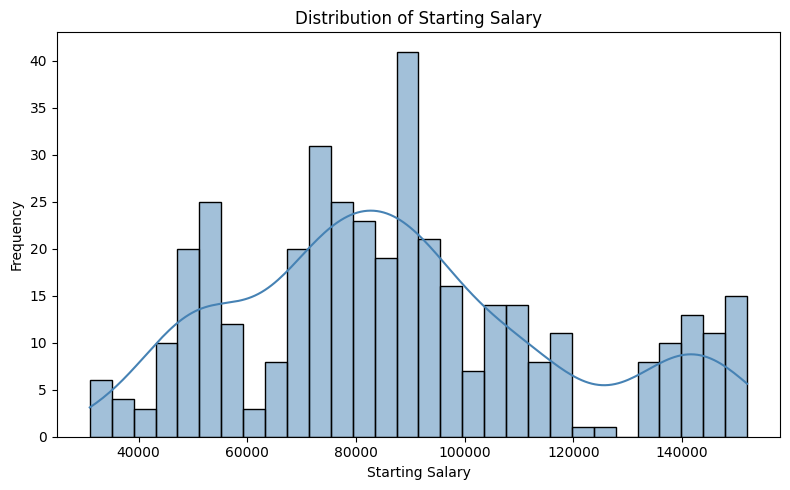

Interpretation: The starting salary distribution shows the spread of graduate salaries.
A roughly normal or skewed distribution helps us understand if outliers exist.


In [10]:
# Visualization 1: Distribution of Starting Salary (Target Variable)
plt.figure(figsize=(8, 5))
sns.histplot(df['Starting_Salary'], bins=30, kde=True, color='steelblue')
plt.title('Distribution of Starting Salary')
plt.xlabel('Starting Salary')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()
print('Interpretation: The starting salary distribution shows the spread of graduate salaries.')
print('A roughly normal or skewed distribution helps us understand if outliers exist.')

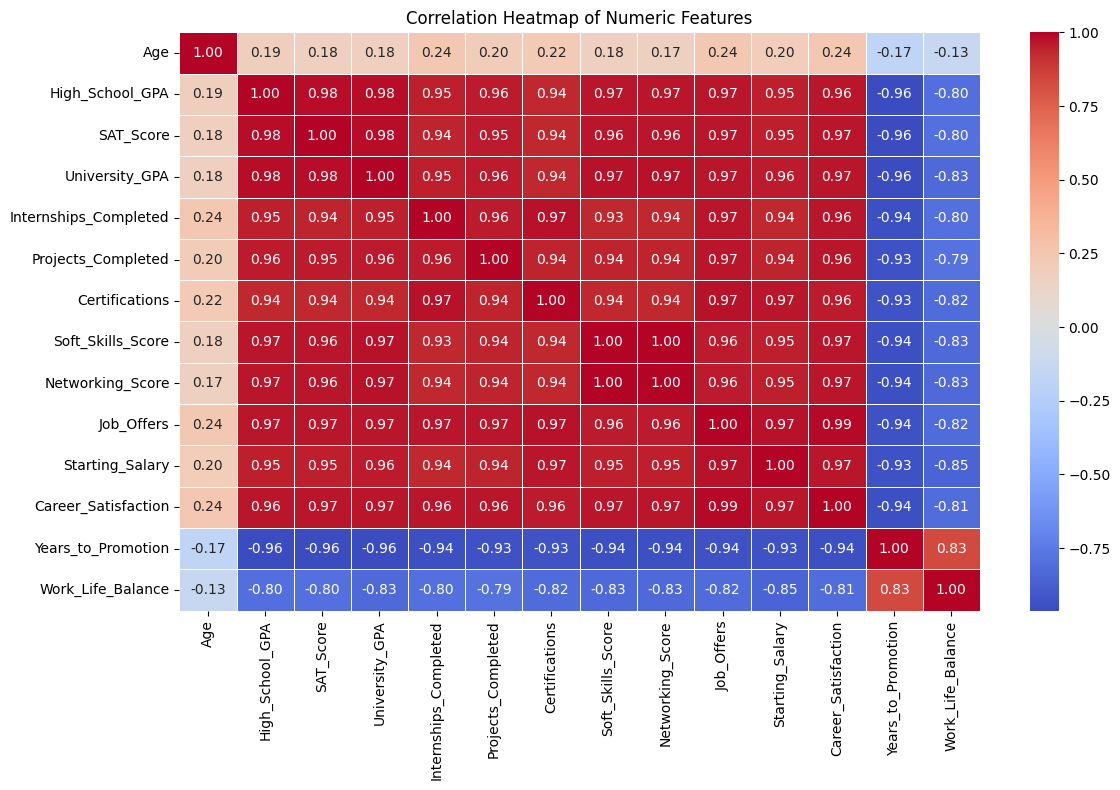

Interpretation: Features highly correlated with Starting_Salary are the strongest predictors.
Features correlated with each other may cause multicollinearity and can be dropped.


In [11]:
# Visualization 2: Correlation Heatmap
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(12, 8))
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.show()
print('Interpretation: Features highly correlated with Starting_Salary are the strongest predictors.')
print('Features correlated with each other may cause multicollinearity and can be dropped.')

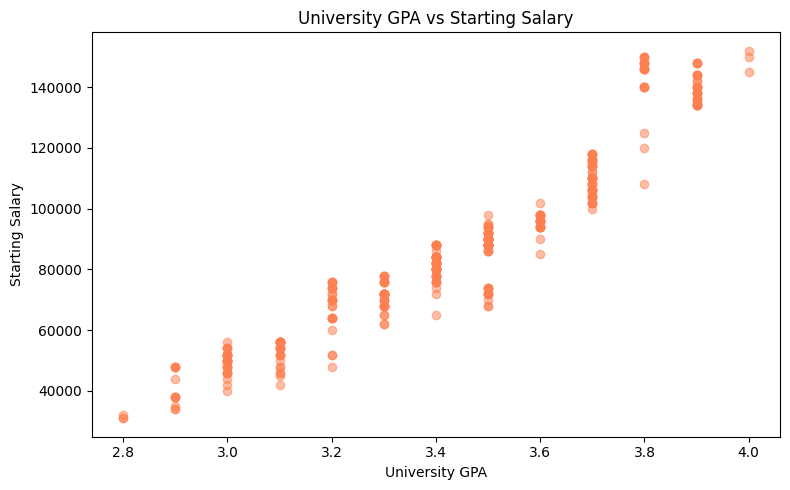

Interpretation: A positive trend between GPA and salary suggests GPA is an important predictor.


In [12]:
# Visualization 3: Scatterplot - University GPA vs Starting Salary
plt.figure(figsize=(8, 5))
plt.scatter(df['University_GPA'], df['Starting_Salary'], alpha=0.5, color='coral')
plt.title('University GPA vs Starting Salary')
plt.xlabel('University GPA')
plt.ylabel('Starting Salary')
plt.tight_layout()
plt.show()
print('Interpretation: A positive trend between GPA and salary suggests GPA is an important predictor.')

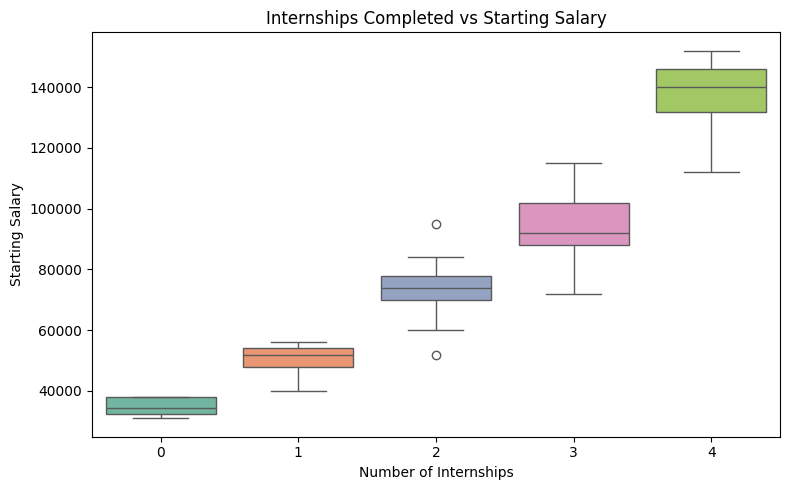

Interpretation: More internships tend to correlate with higher starting salary.


In [13]:
# Visualization 4: Internships Completed vs Starting Salary
plt.figure(figsize=(8, 5))
sns.boxplot(x='Internships_Completed', y='Starting_Salary', data=df, palette='Set2')
plt.title('Internships Completed vs Starting Salary')
plt.xlabel('Number of Internships')
plt.ylabel('Starting Salary')
plt.tight_layout()
plt.show()
print('Interpretation: More internships tend to correlate with higher starting salary.')

##  Step 4: Feature Engineering

In [14]:
# Drop columns that are not useful for prediction
# Student_ID: just an identifier, carries no predictive value
df = df.drop(columns=['Student_ID'])

print('Columns after dropping Student_ID:')
print(df.columns.tolist())

Columns after dropping Student_ID:
['Age', 'Gender', 'High_School_GPA', 'SAT_Score', 'University_GPA', 'Field_of_Study', 'Internships_Completed', 'Projects_Completed', 'Certifications', 'Soft_Skills_Score', 'Networking_Score', 'Job_Offers', 'Starting_Salary', 'Career_Satisfaction', 'Years_to_Promotion', 'Current_Job_Level', 'Work_Life_Balance', 'Entrepreneurship']


In [15]:
# Convert categorical columns to numeric using Label Encoding
# Categorical columns: Gender, Field_of_Study, Current_Job_Level, Entrepreneurship

le = LabelEncoder()

categorical_cols = ['Gender', 'Field_of_Study', 'Current_Job_Level', 'Entrepreneurship']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])
    print(f'{col} encoded successfully')

print('\nAll categorical columns converted to numeric.')
df.head()

Gender encoded successfully
Field_of_Study encoded successfully
Current_Job_Level encoded successfully
Entrepreneurship encoded successfully

All categorical columns converted to numeric.


,Age,Gender,High_School_GPA,SAT_Score,University_GPA,Field_of_Study,Internships_Completed,Projects_Completed,Certifications,Soft_Skills_Score,Networking_Score,Job_Offers,Starting_Salary,Career_Satisfaction,Years_to_Promotion,Current_Job_Level,Work_Life_Balance,Entrepreneurship
0,22,1,3.8,1450,3.6,2,3,7,2,8,7,3,85000,8,2,1,7,0
1,24,0,3.6,1380,3.4,1,2,5,3,7,6,2,65000,7,3,1,6,0
2,21,1,3.9,1520,3.8,4,4,9,4,9,8,4,120000,9,1,2,6,0
3,23,0,3.5,1300,3.2,10,1,3,1,6,5,1,48000,6,4,0,8,0
4,25,1,3.7,1420,3.5,8,2,6,2,8,7,3,95000,8,2,1,5,0


##  Step 5: Define Features & Target, Split Data

In [16]:
# Target: Starting_Salary
# Features: everything else

X = df.drop(columns=['Starting_Salary'])
y = df['Starting_Salary']

print('Features shape:', X.shape)
print('Target shape:', y.shape)
print('\nFeature columns used:')
print(X.columns.tolist())

Features shape: (400, 17)
Target shape: (400,)

Feature columns used:
['Age', 'Gender', 'High_School_GPA', 'SAT_Score', 'University_GPA', 'Field_of_Study', 'Internships_Completed', 'Projects_Completed', 'Certifications', 'Soft_Skills_Score', 'Networking_Score', 'Job_Offers', 'Career_Satisfaction', 'Years_to_Promotion', 'Current_Job_Level', 'Work_Life_Balance', 'Entrepreneurship']


In [17]:
# Train/Test Split - 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Training samples:', X_train.shape[0])
print('Testing samples:', X_test.shape[0])

Training samples: 320
Testing samples: 80


## Step 6: Standardize the Data

In [18]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Data standardized successfully!')
print('Mean of training features (should be ~0):', X_train_scaled.mean(axis=0).round(2))

Data standardized successfully!
Mean of training features (should be ~0): [-0. -0. -0.  0. -0.  0.  0. -0. -0.  0.  0.  0.  0.  0. -0.  0.  0.]


##  Step 7: Train Models

### 7a. Linear Regression (scikit-learn)

In [19]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

y_pred_lr_train = lr_model.predict(X_train_scaled)
y_pred_lr_test = lr_model.predict(X_test_scaled)

lr_train_mse = mean_squared_error(y_train, y_pred_lr_train)
lr_test_mse = mean_squared_error(y_test, y_pred_lr_test)
lr_r2 = r2_score(y_test, y_pred_lr_test)

print('=== Linear Regression ===')
print(f'Train MSE: {lr_train_mse:.2f}')
print(f'Test MSE:  {lr_test_mse:.2f}')
print(f'R² Score:  {lr_r2:.4f}')

=== Linear Regression ===
Train MSE: 19594473.85
Test MSE:  17593758.81
R² Score:  0.9813


### 7b. Decision Tree Regressor

In [20]:
dt_model = DecisionTreeRegressor(random_state=42, max_depth=5)
dt_model.fit(X_train_scaled, y_train)

y_pred_dt_train = dt_model.predict(X_train_scaled)
y_pred_dt_test = dt_model.predict(X_test_scaled)

dt_train_mse = mean_squared_error(y_train, y_pred_dt_train)
dt_test_mse = mean_squared_error(y_test, y_pred_dt_test)
dt_r2 = r2_score(y_test, y_pred_dt_test)

print('=== Decision Tree ===')
print(f'Train MSE: {dt_train_mse:.2f}')
print(f'Test MSE:  {dt_test_mse:.2f}')
print(f'R² Score:  {dt_r2:.4f}')

=== Decision Tree ===
Train MSE: 4845100.61
Test MSE:  8365615.83
R² Score:  0.9911


### 7c. Random Forest Regressor

In [21]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

y_pred_rf_train = rf_model.predict(X_train_scaled)
y_pred_rf_test = rf_model.predict(X_test_scaled)

rf_train_mse = mean_squared_error(y_train, y_pred_rf_train)
rf_test_mse = mean_squared_error(y_test, y_pred_rf_test)
rf_r2 = r2_score(y_test, y_pred_rf_test)

print('=== Random Forest ===')
print(f'Train MSE: {rf_train_mse:.2f}')
print(f'Test MSE:  {rf_test_mse:.2f}')
print(f'R² Score:  {rf_r2:.4f}')

=== Random Forest ===
Train MSE: 906579.52
Test MSE:  5007462.18
R² Score:  0.9947


##  Step 8: Loss Curve using Gradient Descent (SGDRegressor)

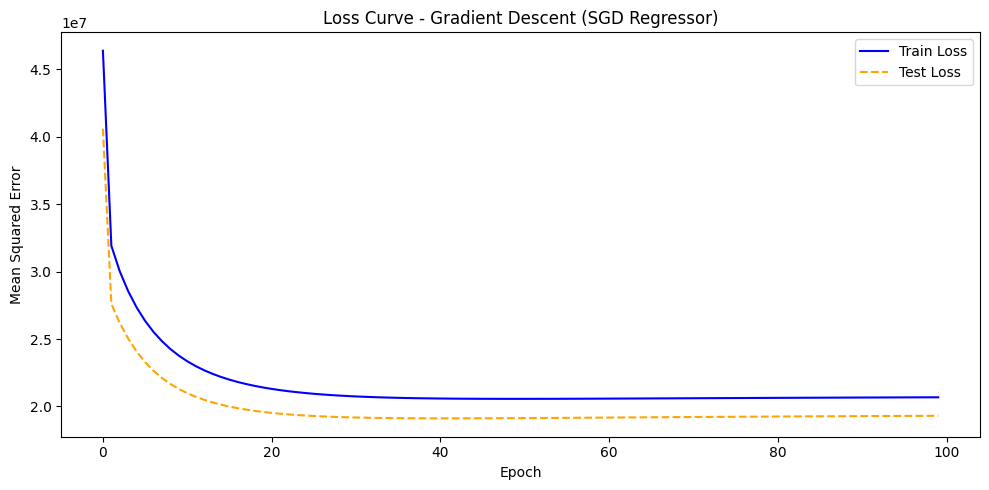

Interpretation: As epochs increase, both train and test loss should decrease,
showing the model is learning. A gap between them may indicate overfitting.


In [22]:
# SGDRegressor allows us to train epoch by epoch and track loss

train_losses = []
test_losses = []

sgd_model = SGDRegressor(max_iter=1, warm_start=True, random_state=42, eta0=0.01, learning_rate='constant')

epochs = 100

for epoch in range(epochs):
    sgd_model.fit(X_train_scaled, y_train)
    train_pred = sgd_model.predict(X_train_scaled)
    test_pred = sgd_model.predict(X_test_scaled)
    train_losses.append(mean_squared_error(y_train, train_pred))
    test_losses.append(mean_squared_error(y_test, test_pred))

# Plot the loss curve
plt.figure(figsize=(10, 5))
plt.plot(range(epochs), train_losses, label='Train Loss', color='blue')
plt.plot(range(epochs), test_losses, label='Test Loss', color='orange', linestyle='--')
plt.title('Loss Curve - Gradient Descent (SGD Regressor)')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.tight_layout()
plt.show()

print('Interpretation: As epochs increase, both train and test loss should decrease,')
print('showing the model is learning. A gap between them may indicate overfitting.')

##  Step 9: Scatter Plot — Before & After Linear Regression Line

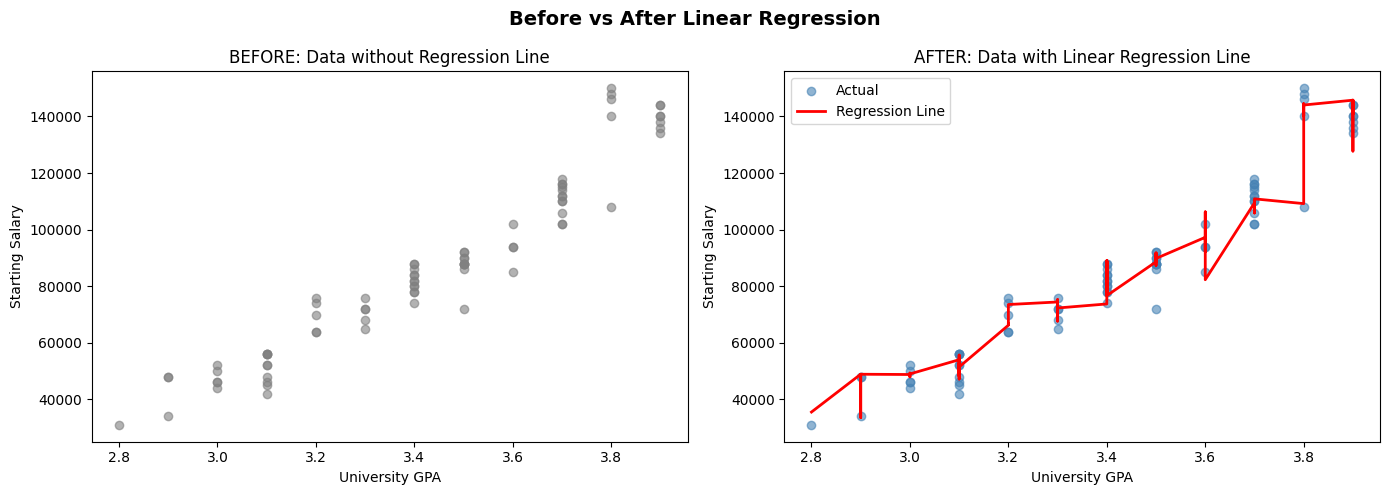

In [23]:
# We use University_GPA as the main feature to visualize the regression line

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# BEFORE: Raw scatter (no line)
axes[0].scatter(X_test['University_GPA'], y_test, color='gray', alpha=0.6)
axes[0].set_title('BEFORE: Data without Regression Line')
axes[0].set_xlabel('University GPA')
axes[0].set_ylabel('Starting Salary')

# AFTER: Scatter + regression line from Linear Regression predictions
sorted_idx = X_test['University_GPA'].argsort()
axes[1].scatter(X_test['University_GPA'], y_test, color='steelblue', alpha=0.6, label='Actual')
axes[1].plot(
    X_test['University_GPA'].values[sorted_idx],
    y_pred_lr_test[sorted_idx],
    color='red', linewidth=2, label='Regression Line'
)
axes[1].set_title('AFTER: Data with Linear Regression Line')
axes[1].set_xlabel('University GPA')
axes[1].set_ylabel('Starting Salary')
axes[1].legend()

plt.suptitle('Before vs After Linear Regression', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

##
 Step 10: Compare Models & Save the Best One

In [24]:
# Summary table
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'Train MSE': [lr_train_mse, dt_train_mse, rf_train_mse],
    'Test MSE': [lr_test_mse, dt_test_mse, rf_test_mse],
    'R² Score': [lr_r2, dt_r2, rf_r2]
})

print(results.to_string(index=False))

# Find best model (lowest test MSE)
best_idx = results['Test MSE'].idxmin()
best_model_name = results.loc[best_idx, 'Model']
print(f'\n✅ Best Model: {best_model_name} (Lowest Test MSE)')

            Model    Train MSE     Test MSE  R² Score
Linear Regression 1.959447e+07 1.759376e+07  0.981300
    Decision Tree 4.845101e+06 8.365616e+06  0.991109
    Random Forest 9.065795e+05 5.007462e+06  0.994678

✅ Best Model: Random Forest (Lowest Test MSE)


In [25]:
# Save the best model
models_map = {
    'Linear Regression': lr_model,
    'Decision Tree': dt_model,
    'Random Forest': rf_model
}

best_model = models_map[best_model_name]

joblib.dump(best_model, 'best_model.joblib')
joblib.dump(scaler, 'scaler.joblib')

print(f'✅ Best model ({best_model_name}) saved as best_model.joblib')
print('✅ Scaler saved as scaler.joblib')

✅ Best model (Random Forest) saved as best_model.joblib
✅ Scaler saved as scaler.joblib


##  Step 11: Make a Prediction on One Row from Test Data

In [26]:
# Load the saved model & scaler
loaded_model = joblib.load('best_model.joblib')
loaded_scaler = joblib.load('scaler.joblib')

# Take 1 row from the test set
sample = X_test.iloc[[0]]  # first row of test data
actual_salary = y_test.iloc[0]

# Scale and predict
sample_scaled = loaded_scaler.transform(sample)
predicted_salary = loaded_model.predict(sample_scaled)[0]

print('=== Single Prediction ===')
print(f'Input features:\n{sample.to_string()}\n')
print(f'Actual Starting Salary:    ${actual_salary:,.2f}')
print(f'Predicted Starting Salary: ${predicted_salary:,.2f}')
print(f'Difference:                ${abs(actual_salary - predicted_salary):,.2f}')

=== Single Prediction ===
Input features:
     Age  Gender  High_School_GPA  SAT_Score  University_GPA  Field_of_Study  Internships_Completed  Projects_Completed  Certifications  Soft_Skills_Score  Networking_Score  Job_Offers  Career_Satisfaction  Years_to_Promotion  Current_Job_Level  Work_Life_Balance  Entrepreneurship
209   25       0              3.5       1280             3.2               6                      2                   6               2                  7                 6           2                    7                   4                  1                  7                 0

Actual Starting Salary:    $76,000.00
Predicted Starting Salary: $75,600.00
Difference:                $400.00
